# **Unit-Linked Insurance Product Simulation: GMDB Design, Lapse Behavior, and Profit Analysis ( lapse rate 20% )**

## **❗ 架構與主程式相同。用 scenario-based 方式固定其他參數，調整 lapse rate 到 20% ，觀察對 PV profit 的影響**

---

## **1. Project overview**



本專案建立投資型保單（Unit-Linked Insurance）的 Monte Carlo Simulation 模型，參考實際商品設計，分析保戶解約行為對死亡給付、死亡成本與公司獲利的影響。

模型結合三個重要元素:
1. 使用 Geometric Brownian Motion（GBM）模擬投資標的報酬路徑，透過 Monte Carlo 生成帳戶價值（Account Value, AV）的分布。  
2. 參考實際商品保單結構、死亡率與 COI 費率，計算死亡給付（Death Benefit, DB）與保險公司承擔之死亡成本（Death Cost, DC）。  
3. 引入動態解約模型（dynamic lapse model），使保戶行為隨帳戶價值、保證水準與市場環境變動。

本專案利用 paired Monte Carlo simulation 設計，在相同市場路徑與死亡隨機數下比較 no lapse 與 with lapse 情境，聚焦在解約行為本身對結果的影響。並透過分布分析與 outcome decomposition，評估 lapse 對平均獲利與尾端風險（tail risk）的影響。


## **2. 程式碼架構**

商品參數設定 -> 隨機路徑生成 -> 逐月保單 Monte Carlo 模擬 ( 包含帳戶價值、死亡、解約模擬及套用保單設計 ) -> 結果呈現、指標計算。

----
初始值設定 ( 參考實際商品保單 )  
投保年齡 = 40歲 男性 ， 躉繳保費 = 1,000,000 (不提領、不追加保費) ， 帳戶價值初值 AV = 997,664

保額 = 1,600,000 ， 保單年限20年 ， 一個月一期 ， 投資報酬率假設
$\mu$ = 0.04, $\sigma$ = 0.1 ， 折現率 = 0.02


##### *程式碼註記 -> COI rate table、mortality table 與商品參數設定

In [1]:
from dataclasses import dataclass, asdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Rate Table Classes
class RateTable:
    def __init__(self, table: dict):
        self.table = table

    def get(self, key: int) -> float:
        if key in self.table:
            return self.table[key]
        else:
            # 超出範圍時，先用最大年齡的值延伸
            max_key = max(self.table.keys())
            return self.table[max_key]

class COITable:
    def __init__(self, male_table: RateTable, female_table: RateTable):
        self.male = male_table
        self.female = female_table

    def get_rate(self, age: int, gender: str) -> float:
        return self.male.get(age) if gender == "M" else self.female.get(age)

class MortalityTable:
    def __init__(self, male_table: RateTable, female_table: RateTable):
        self.male = male_table
        self.female = female_table

    def get_qx(self, age: int, gender: str) -> float:
        return self.male.get(age) if gender == "M" else self.female.get(age)

In [2]:
# 2. Product Config / State / Record / BehaviorModel / RandomScenario
@dataclass
class ProductConfig:
    issue_age: int = 40
    gender: str = "M"
    single_premium: float = 1_000_000
    initial_investment: float = 997_664
    basic_amount: float = 1_600_000

    policy_years: int = 20
    steps_per_year: int = 12

    mu: float = 0.04          # annual expected return
    sigma: float = 0.10       # annual volatility
    discount_rate: float = 0.02

    monthly_fixed_admin_fee: float = 100.0

    def __post_init__(self):
        self.n_steps = self.policy_years * self.steps_per_year


@dataclass
class PolicyState:
    month: int = 0
    age: int = 40
    av: float = 0.0
    cumulative_premium_net: float = 0.0
    alive: bool = True
    lapsed: bool = False
    death_benefit_paid: float = 0.0
    guarantee_base: float = 1600000.0 # 保證基礎


@dataclass
class MonthlyRecord:
    month: int
    policy_year: int
    age: int
    av_bof: float
    admin_fee: float
    coi: float
    total_fee: float
    fund_return: float
    av_eom: float
    nar: float
    surrender_charge: float
    surrender_value: float
    alive: bool
    lapsed: bool
    death_benefit_paid: float
    guarantee_base: float


In [3]:
# COI table
male_coi = RateTable({
    40: 12.606, 41: 13.745, 42: 14.957, 43: 16.269, 44: 17.663,
    45: 19.940, 46: 21.508, 47: 23.174, 48: 24.940, 49: 26.813,
    50: 28.562, 51: 30.657, 52: 32.893, 53: 35.277, 54: 37.826,
    55: 41.745, 56: 44.682, 57: 47.867, 58: 51.332, 59: 55.094, 60: 61.553})

female_coi = RateTable({
    40: 5.396, 41: 5.825, 42: 6.295, 43: 6.790, 44: 7.326,
    45: 8.390, 46: 9.009, 47: 9.669, 48: 10.387, 49: 11.154, 50: 11.748})

coi_table = COITable(male_coi, female_coi)

In [4]:
# Mortality table
male_qx = RateTable({
    40: 0.0015, 41: 0.0016, 42: 0.0017, 43: 0.0018, 44: 0.0019,
    45: 0.0021, 46: 0.0023, 47: 0.0025, 48: 0.0028, 49: 0.0031,
    50: 0.0035, 51: 0.0039, 52: 0.0044, 53: 0.0049, 54: 0.0055,
    55: 0.0062, 56: 0.0070, 57: 0.0079, 58: 0.0089, 59: 0.0100, 60: 0.0112})

female_qx = RateTable({
    40: 0.0008, 41: 0.0009, 42: 0.0010, 43: 0.0011, 44: 0.0012,
    45: 0.0013, 46: 0.0015, 47: 0.0017, 48: 0.0019, 49: 0.0021, 50: 0.0024})

mortality_table = MortalityTable(male_qx, female_qx)

##### *程式碼註記 -> 保戶解約行為模型 ( logistic ) 、產生Random Scenario

In [5]:
class BehaviorModel:
    @staticmethod
    def get_logistic_lapse_prob( av, guaranteed_base, sc_rate, market_return):
        beta0 = -9   # 基礎解約意願 (負值代表大部分人不解約) (係數通常由精算部門根據歷史數據回歸得出)
        beta1 = 2.0    # Moneyness 係數 (賺越多越想走)
        beta2 = -2.0   # 解約費用係數 (費用越高，解約機率大幅下降,用table 裡的 surrender_charge_rate)
        beta3 = 1.5    # 市場報酬係數

        # 計算各項指標
        moneyness = av / max(guaranteed_base, 1)

        # 邏輯回歸的線性組合 (Logit)
        logit_z = (beta0 + beta1 * moneyness + beta2 * sc_rate + beta3 * market_return)
        prob = 1 / (1 + np.exp(-logit_z)) # 透過 Sigmoid 函數轉化為機率 (0~1)
        return prob

@dataclass
class RandomScenario:
    fund_z: np.ndarray      # 每月投資報酬 shock
    death_u: np.ndarray     # 每月死亡 uniform random
    lapse_u: np.ndarray     # 每月解約 uniform random

# 產生固定 scenario
def generate_random_scenario(n_steps: int, seed: int = 42) -> RandomScenario:
    rng = np.random.default_rng(seed)
    return RandomScenario(
        fund_z=rng.normal(size=n_steps),
        death_u=rng.random(size=n_steps),
        lapse_u=rng.random(size=n_steps)
    )

##### *程式碼註記 -> Simulator

In [6]:
class Simulator:
    def __init__(self, config: ProductConfig, coi_table, mortality_table):
        self.config = config
        self.coi_table = coi_table
        self.mortality_table = mortality_table

    # 管理費用函數
    def monthly_admin_fee_rate(self, policy_year, cumulative_premium_net) -> float:
        if policy_year == 1:
            return 0.00216
        elif policy_year == 2:
            return 0.00211
        elif policy_year == 3:
            return 0.00201
        elif policy_year == 4:
            return 0.00175
        else:
            return 0.0

    def monthly_admin_fee(self, av, policy_year, cumulative_premium_net) -> float:
        rate_fee = av * self.monthly_admin_fee_rate(policy_year, cumulative_premium_net)
        fixed_fee = 0 if cumulative_premium_net >= 3_000_000 else self.config.monthly_fixed_admin_fee
        return rate_fee + fixed_fee

    # 保險成本函數
    def Nar(self, av) -> float:  # 甲型：NAR = max(基本保額 - AV, 0)
        return max(self.config.basic_amount - av, 0.0)

    def monthly_coi(self, age, gender, av) -> float:
        nar = self.Nar(av)
        rate = self.coi_table.get_rate(age, gender)
        return nar * rate / 100_000

    def monthly_qx(self, age, gender) -> float:
        q_annual = self.mortality_table.get_qx(age, gender)
        return 1 - (1 - q_annual) ** (1 / 12)

    # 給固定的 z 已經抽好random的
    def simulate_fund_return_from_z(self, z: float) -> float:
        mu_m = self.config.mu / 12
        sigma_m = self.config.sigma / np.sqrt(12)
        return np.exp((mu_m - 0.5 * sigma_m**2) + sigma_m * z) - 1

    def surrender_charge_rate(self, policy_year) -> float:
        table = {1: 0.10, 2: 0.08, 3: 0.06, 4: 0.04}
        return table.get(policy_year, 0.0)

    def step(self, state: PolicyState, scenario: RandomScenario, lapse_mode: str = "dynamic"):
        if not state.alive or state.lapsed:
            return None

        state.month += 1
        t = state.month - 1  # scenario index
        policy_year = (state.month - 1) // 12 + 1 # 將月份轉為保單年度
        state.age = self.config.issue_age + (state.month - 1) // 12

        av_bof = state.av
        admin_fee = self.monthly_admin_fee(av=av_bof, policy_year=policy_year, cumulative_premium_net=state.cumulative_premium_net)
        nar = self.Nar(av_bof)
        coi = self.monthly_coi(age=state.age, gender=self.config.gender, av=av_bof)
        total_fee = admin_fee + coi

        # 1. 「月初狀態」判斷本月是否死亡 死亡判斷：用 scenario.death_u
        qx_m = self.monthly_qx(state.age, self.config.gender)
        if scenario.death_u[t] < qx_m:
            state.alive = False
            state.death_benefit_paid = max(self.config.basic_amount, av_bof)
            state.av = 0.0 #該月死亡帳戶不再進行投資、費用計算

            return MonthlyRecord(
                month=state.month,
                policy_year=policy_year,
                age=state.age,
                av_bof=av_bof,
                admin_fee=0.0,
                coi=0.0,
                total_fee=0.0,
                fund_return=0.0,
                av_eom=state.av,
                nar=nar,
                surrender_charge=0.0,
                surrender_value=0.0,
                alive=state.alive,
                lapsed=state.lapsed,
                death_benefit_paid=state.death_benefit_paid,
                guarantee_base=state.guarantee_base
            )

        # 2. AV 不足 -> 停效
        if state.av < total_fee:
            state.av = 0.0
            state.lapsed = True

            return MonthlyRecord(
                month=state.month,
                policy_year=policy_year,
                age=state.age,
                av_bof=av_bof,
                admin_fee=admin_fee,
                coi=coi,
                total_fee=total_fee,
                fund_return=0.0,
                av_eom=state.av,
                nar=nar,
                surrender_charge=0.0,
                surrender_value=0.0,
                alive=state.alive,
                lapsed=state.lapsed,
                death_benefit_paid=0.0,
                guarantee_base=state.guarantee_base
            )

        # 3. 扣費後套投資報酬：random 用 scenario.fund_z
        state.av -= total_fee
        r = self.simulate_fund_return_from_z(scenario.fund_z[t])
        state.av *= (1 + r)

        # 4. 解約機制：由 lapse_mode 控制
        sc_rate = self.surrender_charge_rate(policy_year)

        if lapse_mode == "no_lapse":
            lapse_p = 0.0
        elif lapse_mode == "dynamic":
            lapse_p = BehaviorModel.get_logistic_lapse_prob(
                av=state.av,
                guaranteed_base=state.guarantee_base,
                sc_rate=sc_rate,
                market_return=r   # 用當月報酬
            )
        else:
            raise ValueError("lapse_mode must be 'no_lapse' or 'dynamic'")

        # 5. 解約隨機數用 scenario.lapse_u
        lapse_trigger = scenario.lapse_u[t] < lapse_p

        if lapse_trigger:
            surrender_charge = state.av * sc_rate
            surrender_value = state.av - surrender_charge
            state.lapsed = True
            state.av = 0.0

            return MonthlyRecord(
                month=state.month,
                policy_year=policy_year,
                age=state.age,
                av_bof=av_bof,
                admin_fee=admin_fee,
                coi=coi,
                total_fee=total_fee,
                fund_return=r,
                av_eom=0.0,
                nar=nar,
                surrender_charge=surrender_charge,
                surrender_value=surrender_value,
                alive=state.alive,
                lapsed=state.lapsed,
                death_benefit_paid=0.0,
                guarantee_base=state.guarantee_base
            )

        return MonthlyRecord(
            month=state.month,
            policy_year=policy_year,
            age=state.age,
            av_bof=av_bof,
            admin_fee=admin_fee,
            coi=coi,
            total_fee=total_fee,
            fund_return=r,
            av_eom=state.av,
            nar=nar,
            surrender_charge=0.0,
            surrender_value=0.0,
            alive=state.alive,
            lapsed=state.lapsed,
            death_benefit_paid=0.0,
            guarantee_base=state.guarantee_base
        )

    # 單一保戶 / 單一路徑
    def run_one_path(self, scenario: RandomScenario, path_id: int = 1, lapse_mode: str = "dynamic") -> pd.DataFrame:
        state = PolicyState(month=0, age=self.config.issue_age, av=self.config.initial_investment, cumulative_premium_net=self.config.single_premium)
        records = []

        for _ in range(self.config.n_steps):
            rec = self.step(state, scenario=scenario, lapse_mode=lapse_mode)
            if rec is None:
                break

            records.append(rec)

            if not state.alive or state.lapsed:
                break

        df = pd.DataFrame([asdict(r) for r in records])

        if len(df) > 0:
            df["path_id"] = path_id
            df["lapse_mode"] = lapse_mode

        return df

    # 多保戶、配對比較：同一保戶跑 no_lapse 與 dynamic 兩次 (在同一隨機世界下有兩個版本：比較final AV、DB 差異/surrender 造成的 cash flow 差異/lapse 對 tail risk 的影響)
    def run_paired_paths(self, n_sims: int, base_seed: int = 42):
        all_no_lapse = []
        all_with_lapse = []
        summary_rows = []

        for i in range(1, n_sims + 1):
            scenario = generate_random_scenario(n_steps=self.config.n_steps, seed=base_seed + i) # seed=base_seed + i 每個保戶的 scenario 不同，但整體 simulation 可重現
            df_no = self.run_one_path(scenario=scenario,path_id=i,lapse_mode="no_lapse")
            df_yes = self.run_one_path(scenario=scenario,path_id=i,lapse_mode="dynamic")

            if len(df_no) == 0 or len(df_yes) == 0:
                continue

            all_no_lapse.append(df_no)
            all_with_lapse.append(df_yes)

            last_no = df_no.iloc[-1]
            last_yes = df_yes.iloc[-1]

            summary_rows.append({
                "path_id": i,

                "final_month_no_lapse": last_no["month"],
                "final_month_with_lapse": last_yes["month"],

                "final_av_no_lapse": last_no["av_eom"],
                "final_av_with_lapse": last_yes["av_eom"],

                "db_no_lapse": last_no["death_benefit_paid"],
                "db_with_lapse": last_yes["death_benefit_paid"],

                "lapsed_no_lapse": bool(last_no["lapsed"]),
                "lapsed_with_lapse": bool(last_yes["lapsed"]),

                "died_no_lapse": last_no["death_benefit_paid"] > 0,
                "died_with_lapse": last_yes["death_benefit_paid"] > 0,
            })

        all_no_lapse_df = pd.concat(all_no_lapse, ignore_index=True) if all_no_lapse else pd.DataFrame()
        all_with_lapse_df = pd.concat(all_with_lapse, ignore_index=True) if all_with_lapse else pd.DataFrame()
        paired_summary_df = pd.DataFrame(summary_rows)

        return all_no_lapse_df, all_with_lapse_df, paired_summary_df

    # 補 0 函數 (Unconditional AV 則將終止保單視為 0，適用於負債估值與 IFRS 17 分析)
    def build_full_paths_with_zero(self, all_paths_df: pd.DataFrame) -> pd.DataFrame:
        if len(all_paths_df) == 0:
            return pd.DataFrame()

        full_rows = []

        for path_id in all_paths_df["path_id"].unique():
            df_p = all_paths_df[all_paths_df["path_id"] == path_id].copy()
            last_month = int(df_p["month"].max())
            full_rows.append(df_p)# 原本已有資料的部分先保留

            # 終止後月份補 0 (surrender value, DB只出現在當期)
            if last_month < self.config.n_steps:
                last_row = df_p.iloc[-1]
                pad_df = pd.DataFrame({
                    "month": np.arange(last_month + 1, self.config.n_steps + 1),
                    "policy_year": ((np.arange(last_month + 1, self.config.n_steps + 1) - 1) // 12) + 1,
                    "age": self.config.issue_age + ((np.arange(last_month + 1, self.config.n_steps + 1) - 1) // 12),
                    "av_bof": 0.0,
                    "admin_fee": 0.0,
                    "coi": 0.0,
                    "total_fee": 0.0,
                    "fund_return": 0.0,
                    "av_eom": 0.0,
                    "nar": 0.0,
                    "surrender_charge": 0.0,
                    "surrender_value": 0.0,
                    "alive": last_row["alive"],
                    "lapsed": last_row["lapsed"], # 區分出是lapse or death終止
                    "death_benefit_paid": 0.0,
                    "guarantee_base": last_row.get("guarantee_base", self.config.basic_amount),
                    "path_id": path_id,
                    "lapse_mode": last_row.get("lapse_mode", None)
                })

                full_rows.append(pad_df)

        full_df = pd.concat(full_rows, ignore_index=True)
        return full_df

##### *程式碼註記 -> 每期Profit計算

In [7]:
def add_profit_column(df: pd.DataFrame, discount_rate) -> pd.DataFrame: # 每期Profit計算
    if df is None or len(df) == 0:
        return pd.DataFrame()
    out = df.copy()

    # Death cost = NAR
    out["death_cost"] = np.maximum(out["death_benefit_paid"] - out["av_bof"], 0.0)
    # Cash inflow
    out["cash_inflow"] = (out["admin_fee"] + out["coi"]+ out["surrender_charge"])
    # Cash outflow
    out["cash_outflow"] = out["death_cost"]
    # Profit
    out["profit"] = out["cash_inflow"] - out["cash_outflow"]
    # Discount
    monthly_r = discount_rate / 12
    out["discount_factor"] = 1 / ((1 + monthly_r) ** out["month"])
    out["pv_profit"] = out["profit"] * out["discount_factor"]

    return out

def summarize_policy_level(df: pd.DataFrame) -> pd.DataFrame:  # 每張保單數據

    # 將 monthly dataframe 彙總成 policy-level dataframe 一列 = 一位保戶(path_id)
    if df is None or len(df) == 0:
        return pd.DataFrame()

    summary = (
        df.groupby("path_id", as_index=False)
        .agg(
            lapse_mode=("lapse_mode", "last"),
            final_month=("month", "max"),
            final_av=("av_eom", "last"),
            total_admin_fee=("admin_fee", "sum"),  # 所有期數收了多少fee/coi
            total_coi=("coi", "sum"),
            total_surrender_charge=("surrender_charge", "sum"),
            total_death_benefit=("death_benefit_paid", "sum"), # db只會出現一次
            total_death_cost=("death_cost", "sum"),  # 真正風險成本
            total_cash_inflow=("cash_inflow", "sum"),
            total_cash_outflow=("cash_outflow", "sum"),
            total_profit=("profit", "sum"),
            total_pv_profit=("pv_profit", "sum"),
            lapsed=("lapsed", "max"),
            alive_last=("alive", "last")
        )
    )

    summary["died"] = summary["total_death_benefit"] > 0
    summary["terminated"] = summary["final_month"] < df["month"].max() if len(df) > 0 else False # 包含death/lapse

    return summary

# 月度平均路徑指標: 每月平均 AV、平均 profit path
def get_monthly_portfolio_metrics(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame()

    monthly = (
        df.groupby("month", as_index=False)
        .agg(
            avg_av=("av_eom", "mean"),
            avg_admin_fee=("admin_fee", "mean"),
            avg_coi=("coi", "mean"),
            avg_surrender_charge=("surrender_charge", "mean"),
            avg_death_cost=("death_cost", "mean"),
            avg_profit=("profit", "mean"),
            avg_pv_profit=("pv_profit", "mean"),
            death_rate_month=("death_benefit_paid", lambda s: (s > 0).mean()),
            lapse_rate_month=("lapsed", "mean")
        )
    )

    return monthly

# 產生每月所有資料dataframe: no_monthly/yes_monthly 每張保單資料: no_policy/yes_policy
def run_full_metrics_pipeline(all_no_lapse_df: pd.DataFrame, all_with_lapse_df: pd.DataFrame, discount_rate: float):

    # 1. 加 monthly profit metrics
    no_monthly = add_profit_column(all_no_lapse_df, discount_rate=discount_rate)
    yes_monthly = add_profit_column(all_with_lapse_df, discount_rate=discount_rate)

    # 2. policy-level summary
    no_policy = summarize_policy_level(no_monthly)
    yes_policy = summarize_policy_level(yes_monthly)

    # 3.monthly portfolio metrics
    no_monthly_metrics = get_monthly_portfolio_metrics(no_monthly)
    yes_monthly_metrics = get_monthly_portfolio_metrics(yes_monthly)

    return {
        "no_monthly": no_monthly,
        "yes_monthly": yes_monthly,
        "no_policy": no_policy,
        "yes_policy": yes_policy,
        "no_monthly_metrics": no_monthly_metrics,
        "yes_monthly_metrics": yes_monthly_metrics,
    }

##### *程式碼註記 -> Output Table + Plot Function

In [8]:
# 基本比較圖表
def build_part2_compare_table(sim, results):
    no_monthly = results["no_monthly"]
    yes_monthly = results["yes_monthly"]

    no_policy = results["no_policy"]
    yes_policy = results["yes_policy"]

    final_month = sim.config.n_steps

    #  full paths（做 unconditional AV 用）
    full_no = sim.build_full_paths_with_zero(no_monthly)
    full_yes = sim.build_full_paths_with_zero(yes_monthly)

    #  No Lapse
    # Final AV - Unconditional
    no_last_full = full_no[full_no["month"] == final_month]
    no_final_av_uncond = no_last_full["av_eom"].mean()

    # Final AV - Conditional
    no_last = no_monthly[no_monthly["month"] == final_month]
    no_cond_mask = (no_last["alive"]) & (~no_last["lapsed"])
    no_final_av_cond = no_last.loc[no_cond_mask, "av_eom"].mean()

    # Lapse
    no_lapse_rate = no_policy["lapsed"].mean()
    no_avg_lapse_month = no_policy.loc[no_policy["lapsed"], "final_month"].mean()

    # Duration / Death
    no_duration = no_policy["final_month"].mean()
    no_death_rate = no_policy["died"].mean()

    # DB / Death Cost
    no_db_uncond = no_policy["total_death_benefit"].mean()
    no_death_cost_uncond = no_policy["total_death_cost"].mean()

    # With Lapse
    # Final AV - Unconditional
    yes_last_full = full_yes[full_yes["month"] == final_month]
    yes_final_av_uncond = yes_last_full["av_eom"].mean()

    # Final AV - Conditional
    yes_last = yes_monthly[yes_monthly["month"] == final_month]
    yes_cond_mask = (yes_last["alive"]) & (~yes_last["lapsed"])
    yes_final_av_cond = yes_last.loc[yes_cond_mask, "av_eom"].mean()

    # Lapse
    yes_lapse_rate = yes_policy["lapsed"].mean()
    yes_avg_lapse_month = yes_policy.loc[yes_policy["lapsed"], "final_month"].mean()

    # Duration / Death
    yes_duration = yes_policy["final_month"].mean()
    yes_death_rate = yes_policy["died"].mean()

    # DB / Death Cost
    yes_db_uncond = yes_policy["total_death_benefit"].mean()
    yes_death_cost_uncond = yes_policy["total_death_cost"].mean()

    # Build table
    table = pd.DataFrame({
        "Metric": [
            "Unconditional Final AV",
            "Conditional Final AV",
            "Lapse Rate",
            "Avg Lapse Month",
            "Duration",
            "Death Rate",
            "Unconditional Death Benefit (Mean)",
            "Unconditional Death Cost (Mean)"
        ],
        "No Lapse": [
            no_final_av_uncond,
            no_final_av_cond,
            no_lapse_rate,
            no_avg_lapse_month,
            no_duration,
            no_death_rate,
            no_db_uncond,
            no_death_cost_uncond
        ],
        "With Lapse": [
            yes_final_av_uncond,
            yes_final_av_cond,
            yes_lapse_rate,
            yes_avg_lapse_month,
            yes_duration,
            yes_death_rate,
            yes_db_uncond,
            yes_death_cost_uncond
        ]
    })

    def fmt(x):
        if pd.isna(x):
            return ""
        return f"{x:,.4f}"

    for col in ["No Lapse", "With Lapse"]:
        table[col] = table[col].apply(fmt)
    table["Metric"] = table["Metric"].apply(lambda x: f"{x:<25}")
    return table
def plot_av_paths_4lines(sim, results):
    no_monthly = results["no_monthly"]
    yes_monthly = results["yes_monthly"]

    #  full paths（做 unconditional）
    full_no = sim.build_full_paths_with_zero(no_monthly)
    full_yes = sim.build_full_paths_with_zero(yes_monthly)

    #  No Lapse - Unconditional
    no_uncond = (full_no.groupby("month", as_index=False)["av_eom"].mean().rename(columns={"av_eom": "no_uncond"}))

    #  No Lapse - Conditional
    no_cond_df = no_monthly[(no_monthly["alive"]) & (~no_monthly["lapsed"])]
    no_cond = (no_cond_df.groupby("month", as_index=False)["av_eom"].mean().rename(columns={"av_eom": "no_cond"}))

    #  With Lapse - Unconditional
    yes_uncond = (full_yes.groupby("month", as_index=False)["av_eom"].mean().rename(columns={"av_eom": "yes_uncond"}))

    #  With Lapse - Conditional
    yes_cond_df = yes_monthly[(yes_monthly["alive"]) & (~yes_monthly["lapsed"])]
    yes_cond = (yes_cond_df.groupby("month", as_index=False)["av_eom"].mean().rename(columns={"av_eom": "yes_cond"}))

    #  merge
    plot_df = no_uncond.merge(no_cond, on="month", how="left")
    plot_df = plot_df.merge(yes_uncond, on="month", how="left")
    plot_df = plot_df.merge(yes_cond, on="month", how="left")

    #  plot
    plt.figure(figsize=(10, 5))

    plt.plot(plot_df["month"], plot_df["no_uncond"], label="No Lapse - Unconditional AV")
    plt.plot(plot_df["month"], plot_df["no_cond"], label="No Lapse - Conditional AV")
    plt.plot(plot_df["month"], plot_df["yes_uncond"], label="With Lapse - Unconditional AV")
    plt.plot(plot_df["month"], plot_df["yes_cond"], label="With Lapse - Conditional AV")

    plt.xlabel("Month")
    plt.ylabel("Average Account Value")
    plt.title("AV Paths: No Lapse vs With Lapse")
    plt.legend()
    plt.grid(True)
    plt.show()

# DB、DC Table
def build_part2_table2_compare(no_policy: pd.DataFrame, yes_policy: pd.DataFrame) -> pd.DataFrame: # 只看死亡保戶
    no_died = no_policy[no_policy["died"]]
    yes_died = yes_policy[yes_policy["died"]]

    def stats(series):
        if len(series) == 0:
            return [np.nan, np.nan, np.nan, np.nan, np.nan]
        return [series.mean(), series.median(), np.percentile(series, 95), np.percentile(series, 99), series.max()]
    # DB
    no_db_stats = stats(no_died["total_death_benefit"])
    yes_db_stats = stats(yes_died["total_death_benefit"])
    # Death Cost
    no_cost_stats = stats(no_died["total_death_cost"])
    yes_cost_stats = stats(yes_died["total_death_cost"])

    table = pd.DataFrame({"Metric": ["Mean", "Median", "P95", "P99", "Max"], "DB (No Lapse)": no_db_stats,
        "DB (With Lapse)": yes_db_stats,"Death Cost (No Lapse)": no_cost_stats, "Death Cost (With Lapse)": yes_cost_stats })

    def fmt(x):
        if pd.isna(x):
            return ""
        return f"{x:,.4f}"

    for col in ["DB (No Lapse)", "DB (With Lapse)", "Death Cost (No Lapse)", "Death Cost (With Lapse)"]:
        table[col] = table[col].apply(fmt)

    table["Metric"] = table["Metric"].apply(lambda x: f"{x:<25}")

    return table
# DB圖
def plot_db_distribution_compare(no_policy, yes_policy):

    no_db = no_policy.loc[no_policy["died"], "total_death_benefit"]
    yes_db = yes_policy.loc[yes_policy["died"], "total_death_benefit"]

    plt.figure(figsize=(8,5))

    plt.hist(no_db, bins=50, alpha=0.5, label="No Lapse")
    plt.hist(yes_db, bins=50, alpha=0.5, label="With Lapse")

    plt.title("Death Benefit Distribution (Compare)")
    plt.xlabel("Death Benefit")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)

    plt.show()

def plot_db_distribution_separate(no_policy, yes_policy): # 分開畫

    no_db = no_policy.loc[no_policy["died"], "total_death_benefit"]
    yes_db = yes_policy.loc[yes_policy["died"], "total_death_benefit"]

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.hist(no_db, bins=50)
    plt.title("DB - No Lapse")

    plt.subplot(1,2,2)
    plt.hist(yes_db, bins=50)
    plt.title("DB - With Lapse")

    plt.show()
# DC圖
def plot_dc_distribution_compare(no_policy, yes_policy):

    no_dc = no_policy.loc[no_policy["died"], "total_death_cost"]
    yes_dc = yes_policy.loc[yes_policy["died"], "total_death_cost"]

    plt.figure(figsize=(8,5))
    plt.hist(no_dc, bins=50, alpha=0.5, label="No Lapse")
    plt.hist(yes_dc, bins=50, alpha=0.5, label="With Lapse")

    plt.title("Death Cost Distribution (Compare)")
    plt.xlabel("Death Cost")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()
def plot_dc_distribution_separate(no_policy, yes_policy):

    no_dc = no_policy.loc[no_policy["died"], "total_death_cost"]
    yes_dc = yes_policy.loc[yes_policy["died"], "total_death_cost"]

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.hist(no_dc, bins=50)
    plt.title("Death Cost - No Lapse")

    plt.subplot(1,2,2)
    plt.hist(yes_dc, bins=50)
    plt.title("Death Cost - With Lapse")
    plt.show()

# Profit Table
def build_part2_table3_compare(no_policy: pd.DataFrame, yes_policy: pd.DataFrame) -> pd.DataFrame:
    no_profit = no_policy["total_pv_profit"]
    yes_profit = yes_policy["total_pv_profit"]

    def stats(series):
        if len(series) == 0:
            return [np.nan, np.nan, np.nan, np.nan, np.nan]
        return [series.min(), np.percentile(series, 1), np.percentile(series, 5), series.median(), series.mean(), series.sum()]

    no_stats = stats(no_profit)
    yes_stats = stats(yes_profit)
    table = pd.DataFrame({"Metric": ["Min", "P1", "P5", "Median", "Mean", "Total Profit"], "No Lapse": no_stats, "With Lapse": yes_stats})

    def fmt(x):
        if pd.isna(x):
            return ""
        return f"{x:,.4f}"

    for col in ["No Lapse", "With Lapse"]:
        table[col] = table[col].apply(fmt)

    return table
def plot_profit_distribution_compare(no_policy, yes_policy):


    no_profit = no_policy["total_pv_profit"]
    yes_profit = yes_policy["total_pv_profit"]

    plt.figure(figsize=(8,5))
    plt.hist(no_profit, bins=50, alpha=0.5, label="No Lapse")
    plt.hist(yes_profit, bins=50, alpha=0.5, label="With Lapse")

    plt.axvline(0, linestyle="--")  # break-even
    plt.yscale("log")
    plt.title("PV Profit Distribution (Compare)")
    plt.xlabel("PV Profit")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()
def plot_profit_distribution_separate(no_policy, yes_policy):

    no_profit = no_policy["total_pv_profit"]
    yes_profit = yes_policy["total_pv_profit"]

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.hist(no_profit, bins=50)
    plt.axvline(0, linestyle="--")
    plt.title("Profit - No Lapse (Log Scale)")
    plt.yscale("log")
    plt.subplot(1,2,2)
    plt.yscale("log")
    plt.hist(yes_profit, bins=50)
    plt.axvline(0, linestyle="--")
    plt.title("Profit - With Lapse (Log Scale)")
    plt.show()

# 資料檢查
def build_lapse_impact_detail(no_policy: pd.DataFrame, yes_policy: pd.DataFrame) -> pd.DataFrame: # 比較同一位保戶在 no lapse vs with lapse 下的結果差異。 一列 = 一位保戶

    merged = no_policy.merge(yes_policy, on="path_id", suffixes=("_no_lapse", "_with_lapse"), how="inner")

    # 差異欄位
    merged["diff_db"] = (merged["total_death_benefit_with_lapse"]- merged["total_death_benefit_no_lapse"])
    merged["diff_death_cost"] = (merged["total_death_cost_with_lapse"]- merged["total_death_cost_no_lapse"])
    merged["diff_pv_profit"] = (merged["total_pv_profit_with_lapse"]- merged["total_pv_profit_no_lapse"])
    merged["diff_total_profit"] = (merged["total_profit_with_lapse"] - merged["total_profit_no_lapse"])
    merged["diff_final_month"] = (merged["final_month_with_lapse"]- merged["final_month_no_lapse"])
    merged["diff_final_av"] = (merged["final_av_with_lapse"]- merged["final_av_no_lapse"])

    # 分類 case
    def classify(row):
        died_no = row["died_no_lapse"]
        died_yes = row["died_with_lapse"]
        lapsed_yes = row["lapsed_with_lapse"]

        if (not lapsed_yes) and (died_no == died_yes):
            return "Same outcome"

        if died_no and lapsed_yes and (not died_yes):
            return "Death avoided by lapse"

        if (not died_no) and lapsed_yes and (not died_yes):
            return "Survivor lapsed"

        if died_no and died_yes:
            return "Both died"

        return "Other"

    merged["case_type"] = merged.apply(classify, axis=1)

    return merged

##### *程式碼註記 -> Run simulation & get result

In [9]:
config = ProductConfig()  # 設定年齡、保額、投組參數、折現率
sim = Simulator(config, coi_table, mortality_table)
all_no_lapse_df, all_with_lapse_df, paired_summary_df = sim.run_paired_paths(n_sims=1000, base_seed=100)
results = run_full_metrics_pipeline(all_no_lapse_df, all_with_lapse_df, discount_rate=config.discount_rate)  #產生：no_monthly / yes_monthly / no_policy / yes_policy

## **3. 模擬結果分析**
採用 paired simulation ( 同一位保戶在兩種情境下共用相同資產路徑與死亡亂數 )。

### **3.1 No Lapse / With Lapse 模型基本比較結果**


                            Metric       No Lapse     With Lapse
         Unconditional Final AV    1,805,082.3936 1,300,912.0459
         Conditional Final AV      1,947,230.1980 1,755,616.7961
         Lapse Rate                        0.0000         0.1990
         Avg Lapse Month                                151.6834
         Duration                        234.9920       217.7550
         Death Rate                        0.0730         0.0600
Unconditional Death Benefit (Mean)   140,013.8139   107,963.3069
   Unconditional Death Cost (Mean)    19,930.2081    16,913.2485


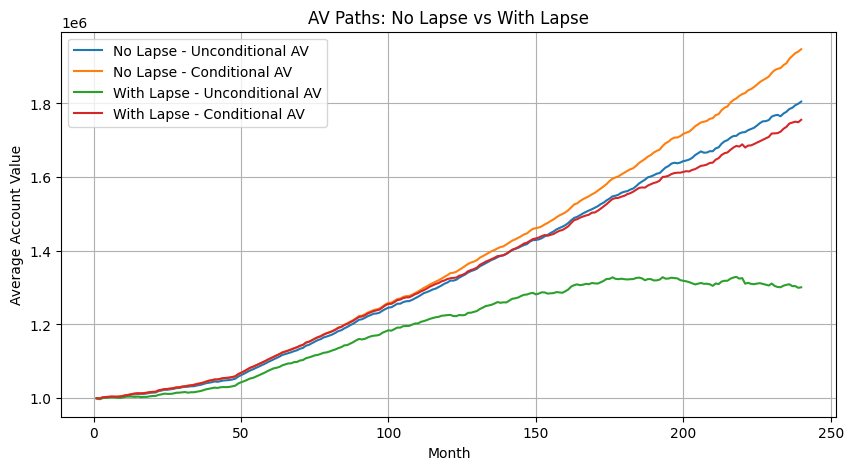

In [10]:
t1_compare = build_part2_compare_table(sim, results)
print(t1_compare.to_string(index=False))
plot_av_paths_4lines(sim, results)

### **3.2 Conditional Death Benefit / Death Cost 分析 (死亡案件情境)**
  


                   Metric  DB (No Lapse) DB (With Lapse) Death Cost (No Lapse) Death Cost (With Lapse)
Mean                      1,917,997.4506  1,799,388.4479          273,016.5489            281,887.4748
Median                    1,600,000.0000  1,600,000.0000          186,248.4303            221,463.8115
P95                       3,079,608.0688  2,782,378.2956          829,880.3162            825,120.7914
P99                       4,406,276.8821  3,084,586.4721          972,626.5051          1,000,330.5542
Max                       5,154,733.7489  3,250,789.7456        1,126,064.3153          1,126,064.3153


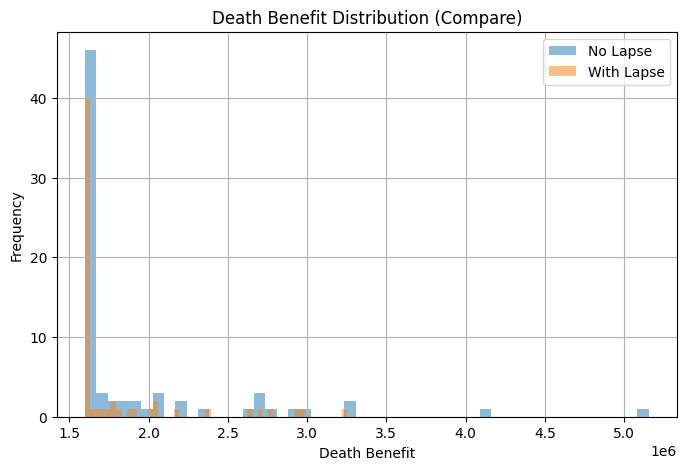

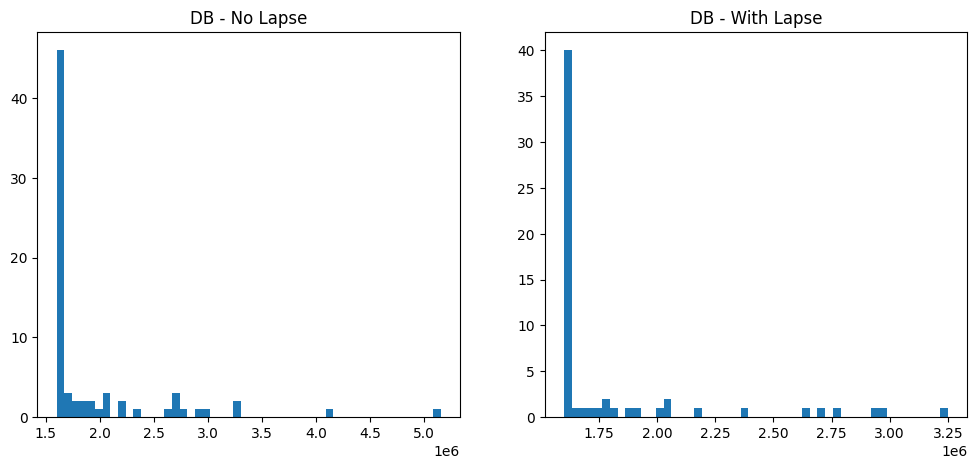

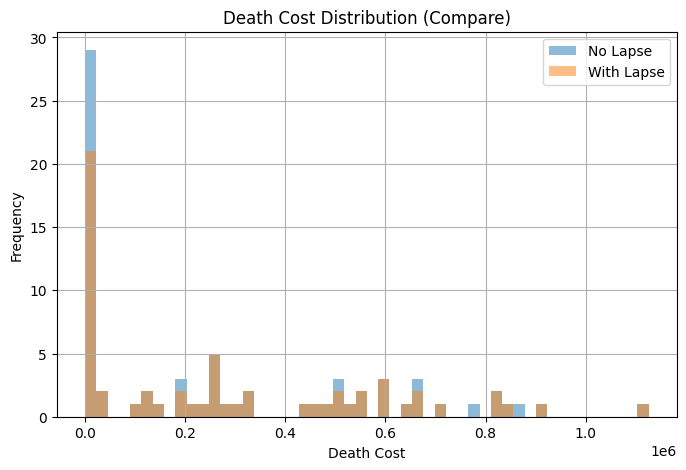

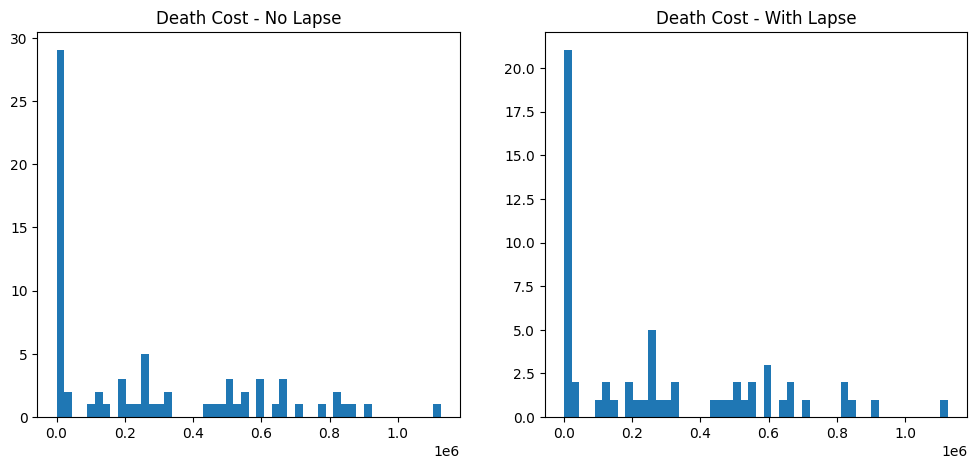

In [11]:
t2_compare = build_part2_table2_compare(results["no_policy"], results["yes_policy"])
print(t2_compare.to_string(index=False))

plot_db_distribution_compare(results["no_policy"], results["yes_policy"])
plot_db_distribution_separate(results["no_policy"], results["yes_policy"])
plot_dc_distribution_compare(results["no_policy"], results["yes_policy"])
plot_dc_distribution_separate(results["no_policy"], results["yes_policy"])

### **3.3 PV profit 分析**




      Metric         No Lapse       With Lapse
         Min    -798,481.0257    -798,481.0257
          P1    -402,261.9864    -391,547.8409
          P5     109,459.5953     104,239.7797
      Median     132,054.6660     130,846.7777
        Mean     117,115.3022     117,513.4618
Total Profit 117,115,302.2221 117,513,461.8085


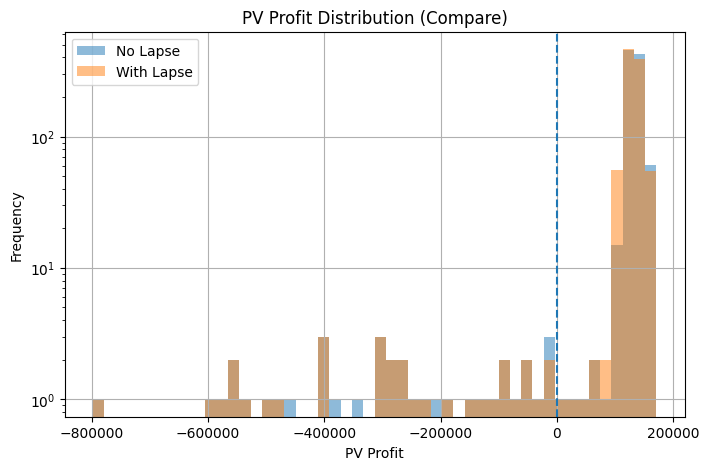

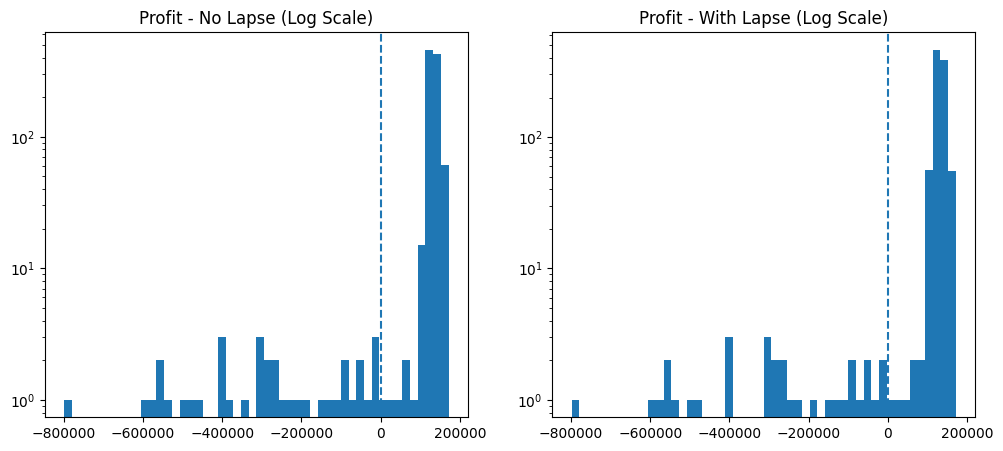

In [12]:
t3_compare = build_part2_table3_compare(results["no_policy"], results["yes_policy"])
print(t3_compare.to_string(index=False))
plot_profit_distribution_compare(results["no_policy"], results["yes_policy"])
plot_profit_distribution_separate(results["no_policy"], results["yes_policy"])

In [13]:
impact_df = build_lapse_impact_detail(results["no_policy"], results["yes_policy"])
print(impact_df["case_type"].value_counts())

case_type
Same outcome              801
Survivor lapsed           186
Death avoided by lapse     13
Name: count, dtype: int64


  ## **4. 總結 :**  
  ## **在當 lapse rate 提高至約 20% 的 scenario 下， DB 下降但 DC 增加，PV profit 略為增加，顯示在此 scenario ，雖然 lapse 會減少未來費用收入，但因為少數原本產生高額 DC 的保戶在死亡前解約，使公司避免大額保證損失的影響更明顯。**

  ---
    
  ## **5. ( 補充 )保戶結果分類檢視**

In [14]:
case_summary = (impact_df.groupby("case_type", as_index=False).agg(
        n=("path_id", "count"),
        avg_db_no_lapse=("total_death_benefit_no_lapse", "mean"),
        avg_db_with_lapse=("total_death_benefit_with_lapse", "mean"),
        avg_dc_no_lapse=("total_death_cost_no_lapse", "mean"),
        avg_dc_with_lapse=("total_death_cost_with_lapse", "mean"),
        avg_pv_profit_no_lapse=("total_pv_profit_no_lapse", "mean"),
        avg_pv_profit_with_lapse=("total_pv_profit_with_lapse", "mean"),
        avg_diff_db=("diff_db", "mean"),
        avg_diff_death_cost=("diff_death_cost", "mean"),
        avg_diff_pv_profit=("diff_pv_profit", "mean"),))

def format_case_summary(df):
    out = df.copy()
    numeric_cols = out.select_dtypes(include="number").columns
    for col in numeric_cols:
        if col == "n":
            out[col] = out[col].astype(int)
        else:
            out[col] = out[col].apply(lambda x: f"{x:,.4f}")
    return out

case_summary_fmt = format_case_summary(case_summary)
print(case_summary_fmt.to_string(index=False))

check = (impact_df.groupby("case_type").agg( n=("path_id", "count"), avg_diff=("diff_pv_profit", "mean")))
check["total_contribution"] = check["n"] * check["avg_diff"]
print("\n", check["total_contribution"].apply(lambda x: f"{x:,.4f}"))
print("\n","Total profit differance:", check["total_contribution"].sum())


             case_type   n avg_db_no_lapse avg_db_with_lapse avg_dc_no_lapse avg_dc_with_lapse avg_pv_profit_no_lapse avg_pv_profit_with_lapse     avg_diff_db avg_diff_death_cost avg_diff_pv_profit
Death avoided by lapse  13  2,465,423.6170            0.0000    232,073.8144            0.0000           -31,992.3232             119,569.8070 -2,465,423.6170       -232,073.8144       151,562.1302
          Same outcome 801    134,785.6515      134,785.6515     21,115.1666       21,115.1666           116,696.0815             116,696.0815          0.0000              0.0000             0.0000
       Survivor lapsed 186          0.0000            0.0000          0.0000            0.0000           129,342.1565             120,889.7473          0.0000              0.0000        -8,452.4092

 case_type
Death avoided by lapse     1,970,307.6921
Same outcome                       0.0000
Survivor lapsed           -1,572,148.1057
Name: total_contribution, dtype: object

 Total profit differance: 398